<a href="https://colab.research.google.com/github/andrewarambula/stock-market-data-analysis/blob/main/stock_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Stock Market Data Analysis

## Objective

This project analyzes the historical performance of several publicly traded companies using Python.

The Analysis Compares:



* Stock Price Performance
* Daily Returns
* Cumulative returns
* Volatility
* Correlation between stocks





 Companies
  
 * Apple (AAPL)
 * Microsoft (MSFT)
 * Nvidia (NVDA)
 * JPMorgan Chase (JPM)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

## 1. Data Collection

Historical stock price data is collected for Apple, Microsoft, Nvidia, and JPMorgan Chase. These companies correlate to different areas of the financial and technology sectors.

In [ ]:
tickers = ["AAPL", "MSFT", "NVDA", "JPM"]

In [ ]:
data = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True

)

[*********************100%***********************]  4 of 4 completed


In [ ]:
data.head()

Price            Close                                           High  \
Ticker            AAPL         JPM        MSFT       NVDA        AAPL   
Date                                                                    
2021-01-04  125.632515  109.000511  207.565430  13.046197  129.709914   
2021-01-05  127.185791  109.593597  207.765640  13.335953  127.894493   
2021-01-06  122.904510  114.739685  202.378403  12.549759  127.224618   
2021-01-07  127.098442  118.507683  208.137436  13.275517  127.787724   
2021-01-08  128.195435  118.638512  209.405594  13.208609  128.758506   

Price                                                 Low              \
Ticker             JPM        MSFT       NVDA        AAPL         JPM   
Date                                                                    
2021-01-04  110.723803  212.628464  13.582431  123.059867  108.056593   
2021-01-05  110.160537  208.356814  13.374504  124.681100  107.953832   
2021-01-06  115.803787  206.421209  13.177023  122.690931  111.538657   
2021-01-07  120.531225  209.138604  13.309094  124.127766  117.679082   
2021-01-08  118.926344  210.320951  13.352118  126.428554  116.981298   

Price                                    Open                          \
Ticker            MSFT       NVDA        AAPL         JPM        MSFT   
Date                                                                    
2021-01-04  204.819371  12.895972  129.622544  110.412051  212.180322   
2021-01-05  205.667963  13.019834  125.127679  109.017933  207.155407   
2021-01-06  202.082823  12.521406  123.991820  113.283090  202.302122   
2021-01-07  203.770462  12.820365  124.613171  118.350691  204.085101   
2021-01-08  206.936057  12.975064  128.564332  118.594898  208.509310   

Price                     Volume                                 
Ticker           NVDA       AAPL       JPM      MSFT       NVDA  
Date                                                             
2021-01-04  13.036995  143301900  16819900  37130100  560640000  
2021-01-05  13.032518   97664900  13731200  23823000  322760000  
2021-01-06  13.154638  155088000  24909100  35930700  580424000  
2021-01-07  12.900949  109578200  21940400  27694500  461480000  
2021-01-08  13.293919  105158200  12035100  22956200  292528000

In [ ]:
prices = data["Close"]

In [ ]:
prices.head()

Ticker,AAPL,JPM,MSFT,NVDA
Date,,,,
2021-01-04,125.632515,109.000511,207.565430,13.046197
2021-01-05,127.185791,109.593597,207.765640,13.335953
2021-01-06,122.904510,114.739685,202.378403,12.549759
2021-01-07,127.098442,118.507683,208.137436,13.275517
2021-01-08,128.195435,118.638512,209.405594,13.208609


## 2. Exploratory Data Analysis

Before examining stock performance, I will evaluate the structure, quality and summary statistics of the dataset.

In [ ]:
prices.shape

(1255, 4)

In [ ]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1255 non-null   float64
 1   JPM     1255 non-null   float64
 2   MSFT    1255 non-null   float64
 3   NVDA    1255 non-null   float64
dtypes: float64(4)
memory usage: 49.0 KB


In [ ]:
prices.isnull().sum()

,0
Ticker,
AAPL,0
JPM,0
MSFT,0
NVDA,0


In [ ]:
prices.describe()

Ticker,AAPL,JPM,MSFT,NVDA
count,1255.000000,1255.000000,1255.000000,1255.000000
mean,179.053881,171.461201,340.563289,67.037403
std,39.983622,60.646535,88.818839,57.341338
min,113.132233,93.369148,202.378403,11.186728
25%,145.694458,128.791237,263.118774,19.345362
50%,171.215530,142.444138,321.873779,41.747864
75%,210.134415,208.490051,411.516830,118.286224
max,285.413116,324.561249,537.646362,206.545151


## Historical Stock Prices

The following visualization compares the adjusted closing prices of each stock across the selected timeframe.

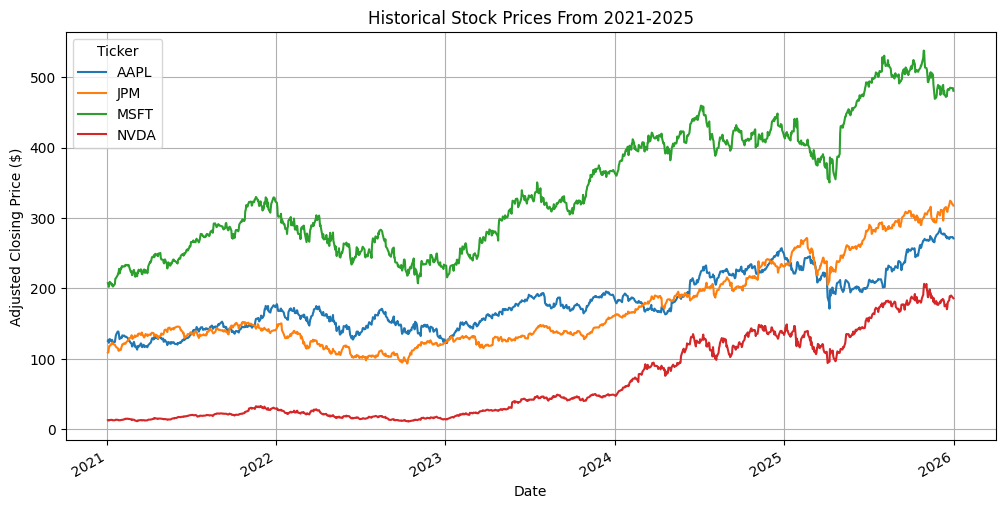

In [ ]:
prices.plot(figsize=(12, 6))

plt.title("Historical Stock Prices From 2021-2025")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price ($)")
plt.grid(True)
plt.show()

## 3. Daily Return Analysis

To compare stock performance more effectively, I will go on to calcuate the daily percentage return for each individual stock. I will carry this out as daily returns evaluate the percentage change in a stock's adjusted closing price between consecutive trading days.

In [ ]:
returns = prices.pct_change()

In [ ]:
returns.head()

Ticker,AAPL,JPM,MSFT,NVDA
Date,,,,
2021-01-04,NaN,NaN,NaN,NaN
2021-01-05,0.012364,0.005441,0.000965,0.022210
2021-01-06,-0.033662,0.046956,-0.025929,-0.058953
2021-01-07,0.034123,0.032840,0.028457,0.057830
2021-01-08,0.008631,0.001104,0.006093,-0.005040


In [ ]:
returns = returns.dropna()

In [ ]:
returns.head()

Ticker,AAPL,JPM,MSFT,NVDA
Date,,,,
2021-01-05,0.012364,0.005441,0.000965,0.022210
2021-01-06,-0.033662,0.046956,-0.025929,-0.058953
2021-01-07,0.034123,0.032840,0.028457,0.057830
2021-01-08,0.008631,0.001104,0.006093,-0.005040
2021-01-11,-0.023249,0.014924,-0.009698,0.025966


In [ ]:
average_daily_returns = returns.mean()

average_daily_returns

,0
Ticker,
AAPL,0.000767
JPM,0.000970
MSFT,0.000800
NVDA,0.002657


In [ ]:
average_daily_returns * 100

,0
Ticker,
AAPL,0.076677
JPM,0.097012
MSFT,0.080050
NVDA,0.265673


## Cumulative Returns

Cumulative returns reflect the total growth of each investment over the analysis timeframe. This allows stocks with different share prices to be compared equally.

In [ ]:
cumulative_returns = (1 + returns).cumprod()

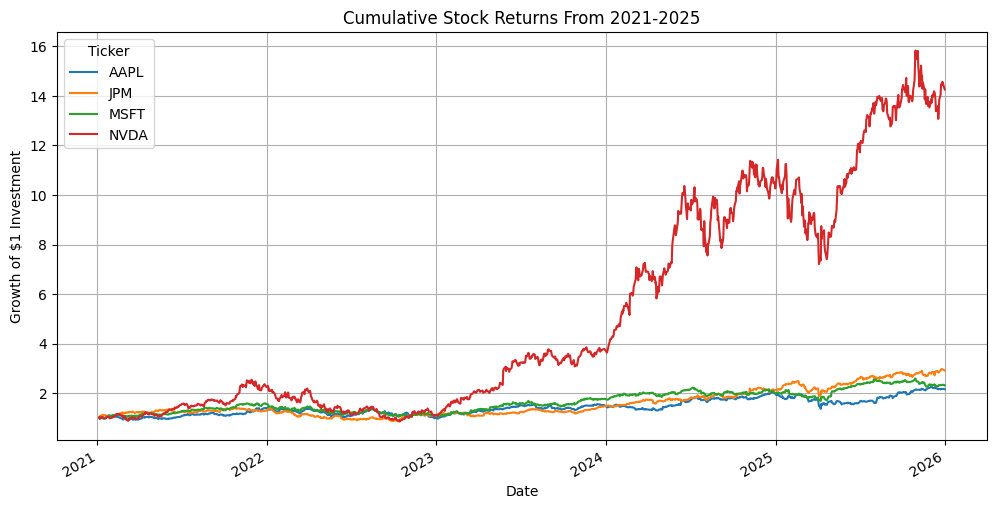

In [ ]:
cumulative_returns.plot(figsize=(12,6))

plt.title("Cumulative Stock Returns From 2021-2025")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.grid(True)
plt.show()

## 4. Volatility Analysis

Return alone does not provide a full visualization of stock performance. Volatility measures how much a stock's returns fluctuate overtime and can be utilized as a metric of risk.

I will move forward with comparing the volatility of each individual stock using the standard deviation of its returns on a daily basis.

In [ ]:
daily_volatility = returns.std()

daily_volatility

,0
Ticker,
AAPL,0.017552
JPM,0.015292
MSFT,0.016198
NVDA,0.032898


In [ ]:
daily_volatility * 100

,0
Ticker,
AAPL,1.755181
JPM,1.529160
MSFT,1.619849
NVDA,3.289845


In [ ]:
import numpy as np

In [ ]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility * 100

,0
Ticker,
AAPL,27.862640
JPM,24.274656
MSFT,25.714306
NVDA,52.224669


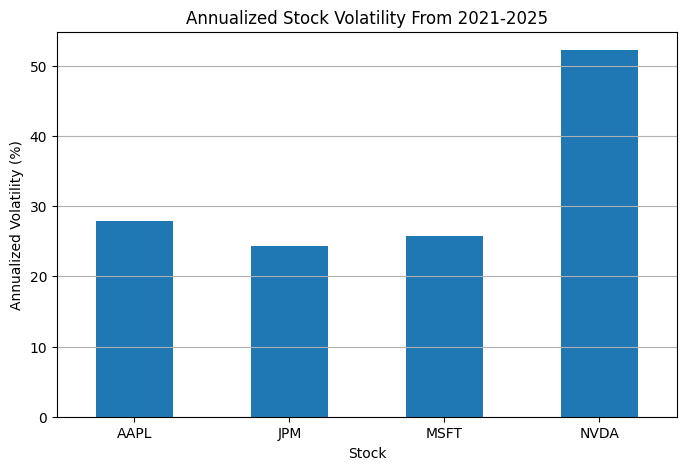

In [ ]:
(annual_volatility * 100).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Annualized Stock Volatility From 2021-2025")
plt.xlabel("Stock")
plt.ylabel("Annualized Volatility (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


## 5. Correlation Analysis

Correlation shows the relationship between the daily returns of two stocks. A correlation closer to 1 implies that the stocks tend to move in the same direction, while a correlation more closely aligned with -1 suggests that they tend to shift in opposite directions.  

In [ ]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,AAPL,JPM,MSFT,NVDA
Ticker,,,,
AAPL,1.000000,0.345422,0.633959,0.519852
JPM,0.345422,1.000000,0.311269,0.315992
MSFT,0.633959,0.311269,1.000000,0.630455
NVDA,0.519852,0.315992,0.630455,1.000000


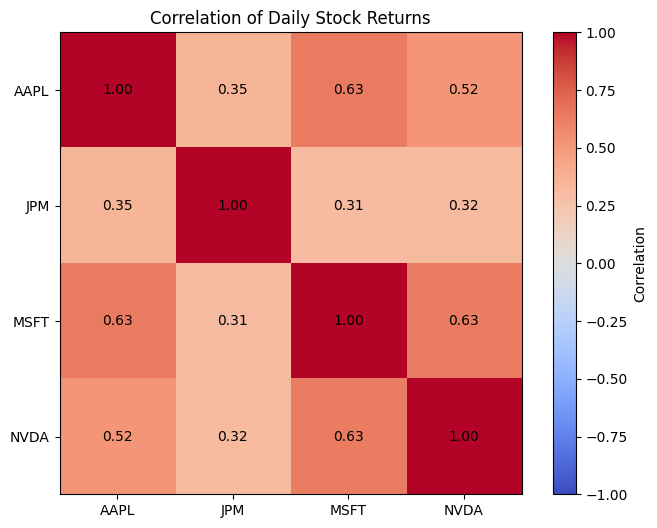

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
  for j in range(len(correlation_matrix.columns)):
    plt.text(
        j,
        i,
        f"{correlation_matrix.iloc[i, j]:.2f}",
        ha="center",
        va="center"
    )

plt.title("Correlation of Daily Stock Returns")
plt.show()

## 6. Key Findings and Conclusion

In performing this analysis, I compared the stock performance of Apple, Microsoft, Nvidia, and JPMorgan Chase from 2021 to 2025.

## Key Findings

- At approximately 0.266%, Nvidia had the highest average daily return compared to the other three stocks during the 2021-2025 time period.

- Nvidia experienced significantly greater cumulative growth over the selected timeframe compared with the other three stocks.

- When comparing the annualized volatility of all four stocks, Nvidia showcased significantly higher volatility. In fact, Apple, Microsoft and JPMorgan Chase had annualized volatility sitting at around 25-28%, whereas Nvidia's annualized volatility was approximately 50-52%. This suggests that Nvidia underwent greater fluctuations in daily returns during the selected time period.

- Microsoft presented moderately strong correlations with both Apple and Nvidia, both correlations measured at approximately 0.63.

- JPMorgan Chase showcased weaker correlations with the other three technology stocks. JPMorgan Chase's correlations with Apple, Microsoft, and Nvidia all fell between 0.31 and 0.35. These results indicate that JPMorgan Chase's daily returns were less closely related to those of the technology stocks during the 2021-2025 period.

## Conclusion

The findings demonstrate that analyzing stock performance involves more than simply comparing stock prices. Accessing returns, volatility, cumulative growth, and correlations offers further insight into both the performance and behavior of different stocks.

This project also showcases how Python and pandas can be utilized to collect, process, evaluate, and visualize real-world financial data.
